In [ ]:

!pip install -q --upgrade torchao
!pip install -q transformers==4.45.0 peft==0.13.0 datasets accelerate
!pip install -q scikit-learn matplotlib seaborn sentencepiece protobuf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 107.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.5/322.5 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 71.6 MB/s eta 0:00:00


In [ ]:

import os, json, re, warnings, random, gc
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq, default_data_collator
)
from peft import LoraConfig, get_peft_model, TaskType

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print("USE GPU}")
else:
  print("USE CPU")

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [ ]:

TRAIN_SIZE = 10000
VAL_SIZE = 2000
TEST_SIZE = 1000
MAX_INPUT_LEN = 256
MAX_TARGET_LEN = 128
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

dataset = load_dataset("yelp_review_full")
print(f"Original train size: {len(dataset['train']):,}")
print(f"Original test size:  {len(dataset['test']):,}")


train_data = dataset["train"].shuffle(seed=SEED).select(range(TRAIN_SIZE))
test_pool = dataset["test"].shuffle(seed=SEED)
val_data = test_pool.select(range(VAL_SIZE))
test_data = test_pool.select(range(VAL_SIZE, VAL_SIZE + TEST_SIZE))

STAR_TO_SENTIMENT = {1: "negative", 2: "negative", 3: "neutral", 4: "positive", 5: "positive"}

FEATURE_KEYWORDS = {
    "food": ["food", "meal", "dish", "taste", "flavor", "cook", "menu", "chicken",
             "pizza", "burger", "steak", "sushi", "salad", "soup", "fries", "rice"],
    "service": ["service", "staff", "waiter", "waitress", "server", "manager",
                "friendly", "rude", "attentive", "slow service", "helpful"],
    "price": ["price", "expensive", "cheap", "cost", "value", "worth", "affordable",
              "overpriced", "bill", "money"],
    "ambiance": ["ambiance", "atmosphere", "decor", "vibe", "music", "loud",
                 "quiet", "cozy", "clean", "dirty", "nice place"],
    "location": ["location", "parking", "area", "neighborhood", "convenient"],
    "quality": ["quality", "fresh", "stale", "excellent", "terrible", "amazing",
                "awful", "best", "worst", "great", "horrible", "good", "bad"],
}

def extract_features(text):
    text_lower = text.lower()
    found = []
    for feat, kws in FEATURE_KEYWORDS.items():
        if any(kw in text_lower for kw in kws):
            found.append(feat)
    return found if found else ["general"]

def build_target(text, label):
    sentiment = STAR_TO_SENTIMENT[label + 1]
    features = extract_features(text)
    summary_text = text[:80].replace("\n", " ").strip()
    if len(text) > 80:
        summary_text += "..."
    target = {
        "overall_sentiment": sentiment,
        "features": features,
        "summary": summary_text
    }
    return json.dumps(target)

INSTRUCTION_TEMPLATE = (
    "Analyze this customer review and extract: overall_sentiment (positive/negative/neutral), "
    "features mentioned, and a brief summary. Output as JSON.\n\nReview: {review}"
)

def format_example(example):
    instruction = INSTRUCTION_TEMPLATE.format(review=example["text"][:300])
    response = build_target(example["text"], example["label"])
    return {"instruction": instruction, "response": response}

train_formatted = train_data.map(format_example)
val_formatted = val_data.map(format_example)
test_formatted = test_data.map(format_example)


print(f"  Train:      {len(train_formatted):,} examples")
print(f"  Validation: {len(val_formatted):,} examples")
print(f"  Test:       {len(test_formatted):,} examples")

print(f"\nSample instruction:\n{train_formatted[0]['instruction'][:200]}...")
print(f"\nSample response:\n{train_formatted[0]['response']}")


from collections import Counter
sentiments = [STAR_TO_SENTIMENT[ex["label"] + 1] for ex in train_data]
dist = Counter(sentiments)
print(f"\nSentiment distribution: {dict(dist)}")

Loading Yelp Review Full dataset...


README.md: 0.00B [00:00, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…):   0%|          | 0.00/299M [00:00<?, ?B/s]

yelp_review_full/test-00000-of-00001.par(…):   0%|          | 0.00/23.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

...

Original train size: 650,000
Original test size:  50,000

Formatting datasets...


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]


Dataset splits:
  Train:      10,000 examples
  Validation: 2,000 examples
  Test:       1,000 examples

Sample instruction:
Analyze this customer review and extract: overall_sentiment (positive/negative/neutral), features mentioned, and a brief summary. Output as JSON.

Review: I stalk this truck.  I've been to industrial ...

Sample response:
{"overall_sentiment": "positive", "features": ["service", "location"], "summary": "I stalk this truck.  I've been to industrial parks where I pretend to be a tech..."}

Sentiment distribution: {'positive': 4045, 'neutral': 1943, 'negative': 4012}


## Base Model Information


In [ ]:
MODEL_NAME = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
base_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)#

total_params = sum(p.numel() for p in base_model.parameters())
print("Model Loaded")

Loading model: google/flan-t5-base

Model: google/flan-t5-base
Architecture: Encoder-Decoder Transformer (T5)
Total parameters: 247,577,856
Vocab size: 32,100
Model size: ~0.99 GB (FP32)


In [ ]:

def tokenize_function(examples):
    model_inputs = tokenizer(
        examples["instruction"],
        max_length=MAX_INPUT_LEN,
        truncation=True,
        padding="max_length",
    )
    labels = tokenizer(
        text_target=examples["response"],
        max_length=MAX_TARGET_LEN,
        truncation=True,
        padding="max_length",
    )

    label_ids = labels["input_ids"]
    label_ids = [
        [(l if l != tokenizer.pad_token_id else -100) for l in label]
        for label in label_ids
    ]
    model_inputs["labels"] = label_ids
    return model_inputs

tokenized_train = train_formatted.map(tokenize_function, batched=True, remove_columns=train_formatted.column_names)
tokenized_val = val_formatted.map(tokenize_function, batched=True, remove_columns=val_formatted.column_names)
tokenized_test = test_formatted.map(tokenize_function, batched=True, remove_columns=test_formatted.column_names)


sample_labels = tokenized_train[0]["labels"]
non_masked = [l for l in sample_labels if l != -100]
assert len(non_masked) > 0, "ERROR: All labels are -100! Tokenization is broken."
print("Tokenization verified OK!")

Tokenizing datasets...


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]


DEBUG - Sample label length: 128
DEBUG - Non-masked tokens: 57 (should be > 0)
DEBUG - First 10 non-masked: [3, 2, 121, 1890, 1748, 834, 5277, 23, 297, 121]
Tokenization verified OK!


## Evaluation Methods


In [ ]:
def evaluate_model(model, dataset_split, tokenizer, num_samples=200, label="Model"):
    model.eval()
    predictions = []
    references = []
    json_valid = 0
    feature_recalls = []

    indices = list(range(min(num_samples, len(dataset_split))))

    for i in indices:
        example = dataset_split[i]
        input_text = example["instruction"]
        true_response = example["response"]

        inputs = tokenizer(input_text, return_tensors="pt", max_length=MAX_INPUT_LEN,
                          truncation=True).to(device)

        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=MAX_TARGET_LEN,
                                     num_beams=2, early_stopping=True)
        pred_text = tokenizer.decode(outputs[0], skip_special_tokens=True)


        fixed_text = pred_text.strip()
        if not fixed_text.startswith('{'):
            fixed_text = '{' + fixed_text

        is_structured = False
        try:
            if not fixed_text.endswith('}'):
                pred_json = json.loads(fixed_text + '}')
            else:
                pred_json = json.loads(fixed_text)
            is_structured = True
            pred_sent = pred_json.get("overall_sentiment", "unknown").lower()
            pred_feats = set(pred_json.get("features", []))
        except:

            pred_sent = "unknown"
            pred_feats = set()

            sent_match = re.search(r'"overall_sentiment"\s*:\s*"([^"]+)"', pred_text)
            if sent_match:
                pred_sent = sent_match.group(1).lower()
                is_structured = True

            feats_match = re.search(r'"features"\s*:\s*\[(.*?)\]', pred_text)
            if feats_match:
                feats_str = feats_match.group(1)
                pred_feats = set(re.findall(r'"([^"]+)"', feats_str))

            if not is_structured:

                for s in ["positive", "negative", "neutral"]:
                    if s in pred_text.lower():
                        pred_sent = s
                        break

                for f in ["food", "service", "price", "ambiance", "location", "quality"]:
                    if f in pred_text.lower():
                        pred_feats.add(f)

        if is_structured:
            json_valid += 1

        try:
            true_json = json.loads(true_response)
            true_sent = true_json["overall_sentiment"]
            true_feats = set(true_json.get("features", []))
        except:
            true_sent = "unknown"
            true_feats = set()

        predictions.append(pred_sent)
        references.append(true_sent)

        if true_feats:
            recall = len(pred_feats & true_feats) / len(true_feats)
            feature_recalls.append(recall)

        if (i + 1) % 50 == 0:
            print(f"  Processed {i+1}/{len(indices)}")


    labels_list = ["positive", "negative", "neutral"]
    valid_mask = [(r in labels_list and p in labels_list) for r, p in zip(references, predictions)]
    filtered_refs = [r for r, m in zip(references, valid_mask) if m]
    filtered_preds = [p for p, m in zip(predictions, valid_mask) if m]

    accuracy = accuracy_score(filtered_refs, filtered_preds) if filtered_refs else 0
    f1 = f1_score(filtered_refs, filtered_preds, labels=labels_list, average="macro", zero_division=0) if filtered_refs else 0
    avg_feature_recall = np.mean(feature_recalls) if feature_recalls else 0
    json_rate = json_valid / len(indices) if indices else 0

    results = {
        "accuracy": accuracy,
        "f1_macro": f1,
        "feature_recall": avg_feature_recall,
        "json_valid_rate": json_rate,
        "predictions": predictions,
        "references": references,
    }

    print(f"\n{label} Results:")
    print(f"  Sentiment Accuracy: {accuracy:.2%}")
    print(f"  Sentiment F1 (macro): {f1:.2%}")
    print(f"  Feature Recall: {avg_feature_recall:.2%}")
    print(f"  JSON Validity: {json_rate:.2%}")

    return results


In [ ]:
base_results = evaluate_model(base_model, test_formatted, tokenizer, num_samples=200, label="Base Flan-T5")


del base_model
torch.cuda.empty_cache()
gc.collect()
print("\nBase model freed from memory.")

EVALUATING BASE MODEL (Zero-Shot)

Evaluating Base Flan-T5 on 200 samples...
  Processed 50/200
  Processed 100/200
  Processed 150/200
  Processed 200/200

Base Flan-T5 Results:
  Sentiment Accuracy: 80.12%
  Sentiment F1 (macro): 57.93%
  Feature Recall: 0.60%
  JSON Validity: 0.00%

Base model freed from memory.


In [ ]:
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q", "v"],
    bias="none",
)

lora_model = get_peft_model(model, lora_config)

trainable_params = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in lora_model.parameters())
print(f"\nLoRA Applied!")
print(f"  Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")
print(f"  Total parameters:     {total_params:,}")
print(f"  Frozen parameters:    {total_params - trainable_params:,}")

training_args = Seq2SeqTrainingArguments(
    output_dir="./lora_output",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=3e-4,
    weight_decay=0.01,
    warmup_steps=100,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    fp16=False,
    report_to="none",
    seed=SEED,
)

data_collator = default_data_collator

trainer = Seq2SeqTrainer(
    model=lora_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    tokenizer=tokenizer,
)

print("\nStarting LoRA fine-tuning...")
train_result = trainer.train()

print(f"\nTraining complete!")
print(f"  Training Loss: {train_result.training_loss:.4f}")
print(f"  Training Time: {train_result.metrics.get('train_runtime', 0):.0f}s")

train_history = trainer.state.log_history
train_losses = [(h["step"], h["loss"]) for h in train_history if "loss" in h]
eval_losses = [(h["step"], h["eval_loss"]) for h in train_history if "eval_loss" in h]

Loading fresh model for LoRA fine-tuning...

LoRA Applied!
  Trainable parameters: 1,769,472 (0.71%)
  Total parameters:     249,347,328
  Frozen parameters:    247,577,856

Starting LoRA fine-tuning...


Epoch,Training Loss,Validation Loss
1,0.193400,0.162453
2,0.166100,0.143556
3,0.161500,0.144089



Training complete!
  Training Loss: 0.2640
  Training Time: 2640s


In [ ]:
lora_results = evaluate_model(lora_model, test_formatted, tokenizer, num_samples=200, label="LoRA Fine-Tuned")

EVALUATING FINE-TUNED MODEL (LoRA)

Evaluating LoRA Fine-Tuned on 200 samples...
  Processed 50/200
  Processed 100/200
  Processed 150/200
  Processed 200/200

LoRA Fine-Tuned Results:
  Sentiment Accuracy: 73.50%
  Sentiment F1 (macro): 59.60%
  Feature Recall: 82.68%
  JSON Validity: 100.00%


## Project Results and Plots

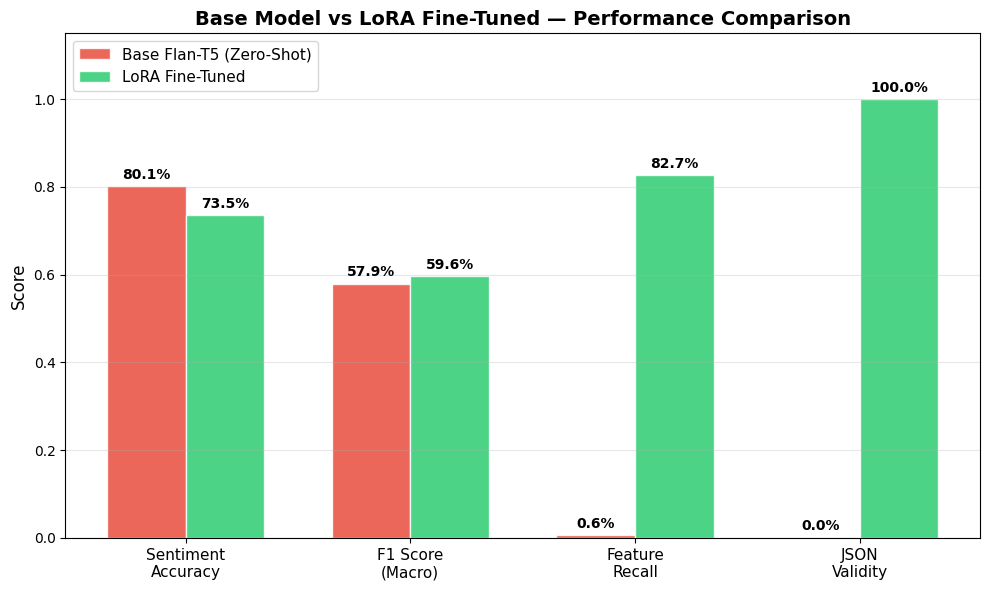

Saved: plot1_comparison.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
metrics = ["Sentiment\nAccuracy", "F1 Score\n(Macro)", "Feature\nRecall", "JSON\nValidity"]
base_vals = [base_results["accuracy"], base_results["f1_macro"],
             base_results["feature_recall"], base_results["json_valid_rate"]]
lora_vals = [lora_results["accuracy"], lora_results["f1_macro"],
             lora_results["feature_recall"], lora_results["json_valid_rate"]]

x = np.arange(len(metrics))
width = 0.35
bars1 = ax.bar(x - width/2, base_vals, width, label="Base Flan-T5 (Zero-Shot)",
               color="#e74c3c", alpha=0.85, edgecolor="white")
bars2 = ax.bar(x + width/2, lora_vals, width, label="LoRA Fine-Tuned",
               color="#2ecc71", alpha=0.85, edgecolor="white")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.1%}", ha="center", va="bottom", fontsize=10, fontweight="bold")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.1%}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("Score", fontsize=12)
ax.set_title("Base Model vs LoRA Fine-Tuned — Performance Comparison", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("plot1_comparison.png", dpi=150)
plt.show()
print("Saved: plot1_comparison.png")

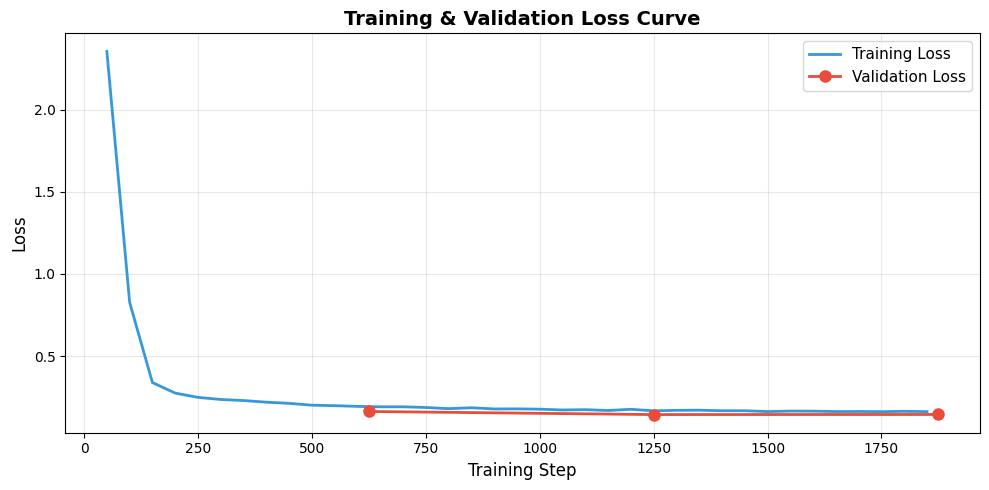

Saved: plot2_loss_curve.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
if train_losses:
    steps, losses = zip(*train_losses)
    ax.plot(steps, losses, color="#3498db", linewidth=2, label="Training Loss")
if eval_losses:
    e_steps, e_losses = zip(*eval_losses)
    ax.plot(e_steps, e_losses, color="#e74c3c", linewidth=2, marker="o",
            markersize=8, label="Validation Loss")
ax.set_xlabel("Training Step", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("Training & Validation Loss Curve", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("plot2_loss_curve.png", dpi=150)
plt.show()

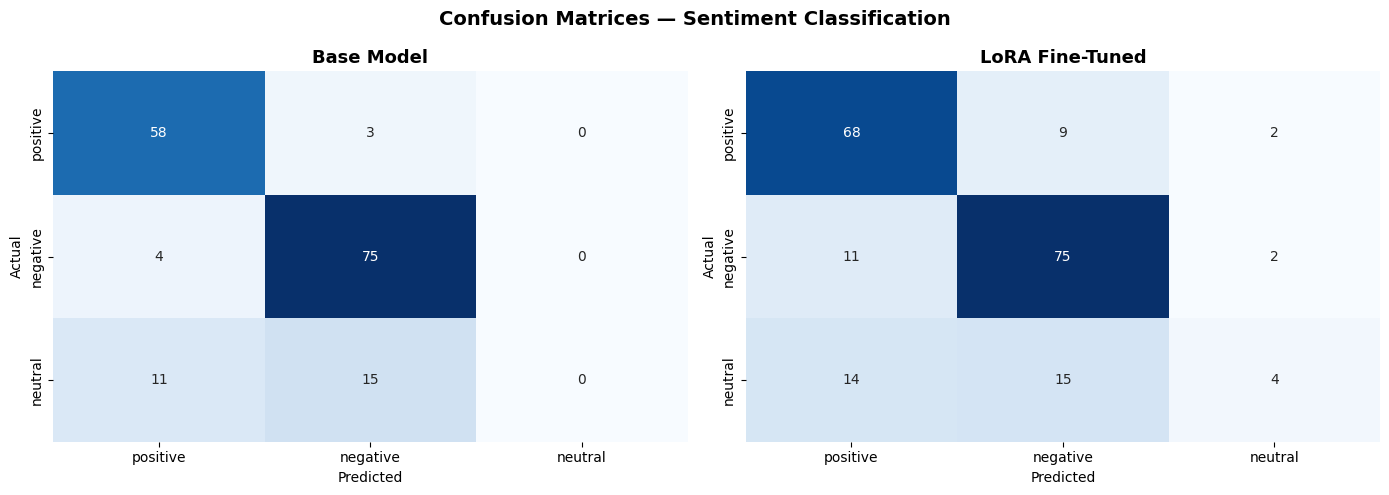

Saved: plot3_confusion.png


In [ ]:
labels_list = ["positive", "negative", "neutral"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, results, title in [
    (axes[0], base_results, "Base Model"),
    (axes[1], lora_results, "LoRA Fine-Tuned"),
]:
    refs = results["references"]
    preds = results["predictions"]
    mask = [(r in labels_list and p in labels_list) for r, p in zip(refs, preds)]
    f_refs = [r for r, m in zip(refs, mask) if m]
    f_preds = [p for p, m in zip(preds, mask) if m]
    if f_refs:
        cm = confusion_matrix(f_refs, f_preds, labels=labels_list)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_list,
                    yticklabels=labels_list, ax=ax, cbar=False)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — Sentiment Classification", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot3_confusion.png", dpi=150)
plt.show()

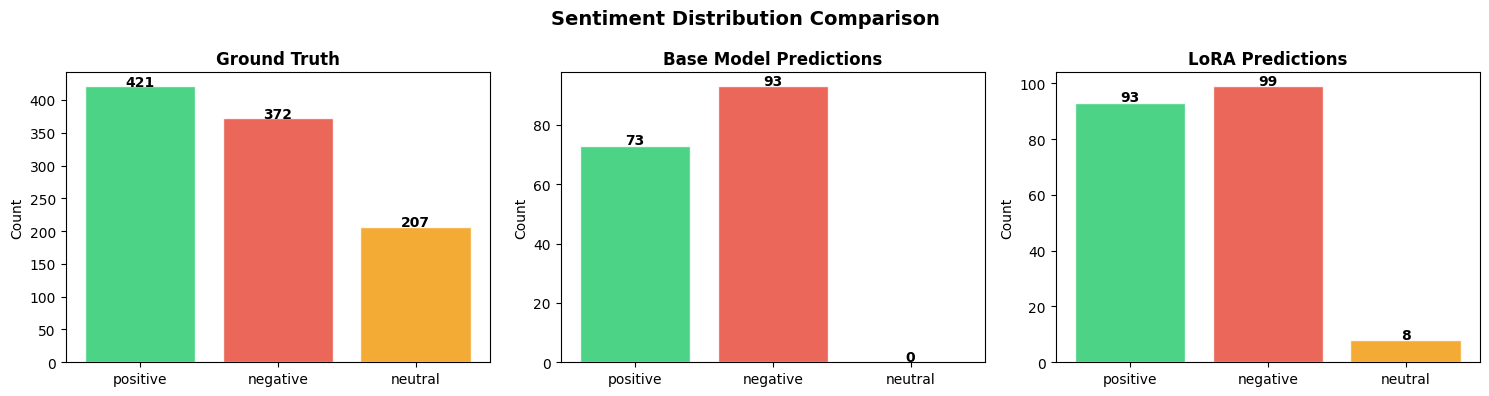

Saved: plot4_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {"positive": "#2ecc71", "negative": "#e74c3c", "neutral": "#f39c12"}

for ax, data, title in [
    (axes[0], [STAR_TO_SENTIMENT[ex["label"]+1] for ex in test_data], "Ground Truth"),
    (axes[1], base_results["predictions"], "Base Model Predictions"),
    (axes[2], lora_results["predictions"], "LoRA Predictions"),
]:
    counts = Counter(data)
    labs = list(colors.keys())
    vals = [counts.get(l, 0) for l in labs]
    ax.bar(labs, vals, color=[colors[l] for l in labs], edgecolor="white", alpha=0.85)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Count")
    for i, v in enumerate(vals):
        ax.text(i, v + 0.5, str(v), ha="center", fontweight="bold")

plt.suptitle("Sentiment Distribution Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot4_distribution.png", dpi=150)
plt.show()

In [ ]:
test_reviews = [
    "The food was absolutely incredible! Best pasta I've ever had. The staff was friendly and attentive. A bit pricey but totally worth it.",
    "Terrible experience. Waited 45 minutes for cold food. The waiter was rude and the place was dirty. Never coming back.",
    "Average place. Nothing special about the food or service. Parking was convenient though. Prices are fair for what you get.",
    "Amazing sushi! Fresh fish, beautiful presentation. The chef clearly knows what he's doing. Great ambiance with soft music.",
    "The burgers are decent but overpriced. Service was okay, nothing memorable. Location is good, right downtown.",
]

results_table = []

for i, review in enumerate(test_reviews):
    instruction = INSTRUCTION_TEMPLATE.format(review=review[:300])
    inputs = tokenizer(instruction, return_tensors="pt", max_length=MAX_INPUT_LEN, truncation=True).to(device)

    with torch.no_grad():
        outputs = lora_model.generate(**inputs, max_new_tokens=MAX_TARGET_LEN, num_beams=2, early_stopping=True)
    pred_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    print(f"\n{'─' * 50}")
    print(f"Review {i+1}: {review[:80]}...")
    print(f"Model Output: {pred_text}")

    try:
        fixed_text = pred_text.strip()
        if not fixed_text.startswith('{'):
            fixed_text = '{' + fixed_text

        if not fixed_text.endswith('}'):
            parsed = json.loads(fixed_text + '}')
        else:
            parsed = json.loads(fixed_text)

        sentiment = parsed.get("overall_sentiment", "N/A")
        features = ", ".join(parsed.get("features", []))
        summary = parsed.get("summary", "N/A")
    except:
        sent_match = re.search(r'"overall_sentiment"\s*:\s*"([^"]+)"', pred_text)
        sentiment = sent_match.group(1) if sent_match else "N/A"

        feats_match = re.search(r'"features"\s*:\s*\[(.*?)\]', pred_text)
        features = ", ".join(re.findall(r'"([^"]+)"', feats_match.group(1))) if feats_match else "N/A"

        summary = pred_text[:80] + "..."

    results_table.append({
        "Review": review[:60] + "...",
        "Sentiment": sentiment,
        "Features": features,
    })

print(f"\n{'=' * 60}")
print("STRUCTURED OUTPUT SUMMARY TABLE")
print("=" * 60)
df = pd.DataFrame(results_table)
print(df.to_string(index=False))


STRUCTURED OUTPUT EXAMPLES

──────────────────────────────────────────────────
Review 1: The food was absolutely incredible! Best pasta I've ever had. The staff was frie...
Model Output: "overall_sentiment": "positive", "features": ["food", "service", "price", "quality"], "summary": "The food was absolutely incredible! Best pasta I've ever had. The staff was friendly..."

──────────────────────────────────────────────────
Review 2: Terrible experience. Waited 45 minutes for cold food. The waiter was rude and th...
Model Output: "overall_sentiment": "negative", "features": ["food", "service", "price", "quality"], "summary": "Terrible experience. Waited 45 minutes for cold food. The waiter was rude and the..."

──────────────────────────────────────────────────
Review 3: Average place. Nothing special about the food or service. Parking was convenient...
Model Output: "overall_sentiment": "neutral", "features": ["food", "service", "price", "quality"], "summary": "Average place. Nothing sp

In [ ]:
comparison = pd.DataFrame({
    "Metric": ["Sentiment Accuracy", "F1 Score (Macro)", "Feature Recall", "JSON Validity Rate"],
    "Base Model": [f"{base_results['accuracy']:.2%}", f"{base_results['f1_macro']:.2%}",
                   f"{base_results['feature_recall']:.2%}", f"{base_results['json_valid_rate']:.2%}"],
    "LoRA Fine-Tuned": [f"{lora_results['accuracy']:.2%}", f"{lora_results['f1_macro']:.2%}",
                        f"{lora_results['feature_recall']:.2%}", f"{lora_results['json_valid_rate']:.2%}"],
})
print(comparison.to_string(index=False))

improvement = lora_results["accuracy"] - base_results["accuracy"]
print(f"\nSentiment Accuracy Improvement: +{improvement:.2%}")
print(f"JSON Validity Improvement: +{lora_results['json_valid_rate'] - base_results['json_valid_rate']:.2%}")
print("\nProject complete!")


FINAL RESULTS COMPARISON
            Metric Base Model LoRA Fine-Tuned
Sentiment Accuracy     80.12%          73.50%
  F1 Score (Macro)     57.93%          59.60%
    Feature Recall      0.60%          82.68%
JSON Validity Rate      0.00%         100.00%

Sentiment Accuracy Improvement: +-6.62%
JSON Validity Improvement: +100.00%

Project complete!
